# 06 · The business decision engine

A model outputs a probability. A bank needs a **yes/no** decision, and every wrong decision costs money:

- A missed fraud (false negative) ≈ **200** units (loss + chargeback).
- A blocked legit txn (false positive) ≈ **5** units (friction, support).

Because those costs are wildly unequal, the default 0.5 threshold is almost never optimal. We sweep every threshold, compute total cost, and pick the minimum. The deliverable is a single sentence a manager can act on.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)

In [2]:
scores = pd.read_parquet(os.path.join(ART, '03_scores.parquet'))
metrics = pd.read_parquet(os.path.join(ART, '04_metrics.parquet'))
y = scores['y_true'].values

best_model = metrics['auc_pr'].idxmax()
y_score = scores[best_model].values
print('optimising thresholds for the best model:', best_model)
print('cost of a missed fraud :', fu.COST_FALSE_NEGATIVE)
print('cost of a false alarm  :', fu.COST_FALSE_POSITIVE)

optimising thresholds for the best model: xgboost
cost of a missed fraud : 200.0
cost of a false alarm  : 5.0


## Sweep the threshold

`sweep_thresholds` evaluates cost at every cut-off from 0.01 to 0.99 and returns precision, recall and total cost at each. The minimum-cost row is our deployment threshold.

In [3]:
sweep = fu.sweep_thresholds(y, y_score)
best_row = sweep.loc[sweep['cost'].idxmin()]
default_row = sweep.iloc[(sweep['threshold'] - 0.5).abs().argmin()]
print('default 0.5 cost :', f"{default_row['cost']:,.0f}")
print('optimal threshold:', f"{best_row['threshold']:.2f}",
      '| cost:', f"{best_row['cost']:,.0f}")
sweep.head()

default 0.5 cost : 1,830
optimal threshold: 0.02 | cost: 700


,threshold,tp,fp,fn,tn,precision,recall,cost
0,0.0100,47,32,3,14968,0.5949,0.9400,760.0000
1,0.0200,47,20,3,14980,0.7015,0.9400,700.0000
2,0.0300,45,17,5,14983,0.7258,0.9000,"1,085.0000"
3,0.0400,44,15,6,14985,0.7458,0.8800,"1,275.0000"
4,0.0500,44,15,6,14985,0.7458,0.8800,"1,275.0000"


## The cost curve

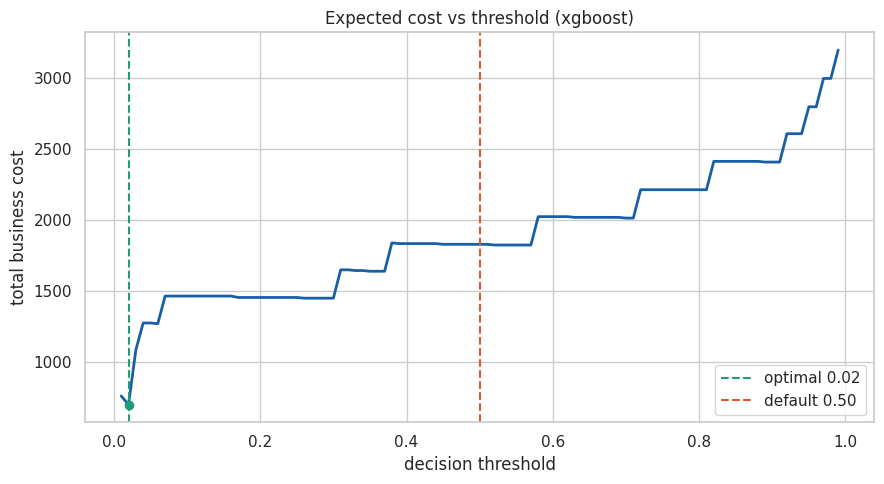

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep['threshold'], sweep['cost'], color='#185FA5', lw=2)
ax.axvline(best_row['threshold'], color='#1D9E75', ls='--',
           label=f"optimal {best_row['threshold']:.2f}")
ax.axvline(0.5, color='#D85A30', ls='--', label='default 0.50')
ax.scatter([best_row['threshold']], [best_row['cost']], color='#1D9E75', zorder=5)
ax.set_xlabel('decision threshold'); ax.set_ylabel('total business cost')
ax.set_title(f'Expected cost vs threshold ({best_model})')
ax.legend(); plt.tight_layout(); plt.show()

## Precision and recall at the chosen threshold

Lowering the threshold catches more fraud (higher recall) at the price of more false alarms (lower precision). The cost-optimal point picks that trade-off *for you*, using the actual cost numbers instead of a gut feel.

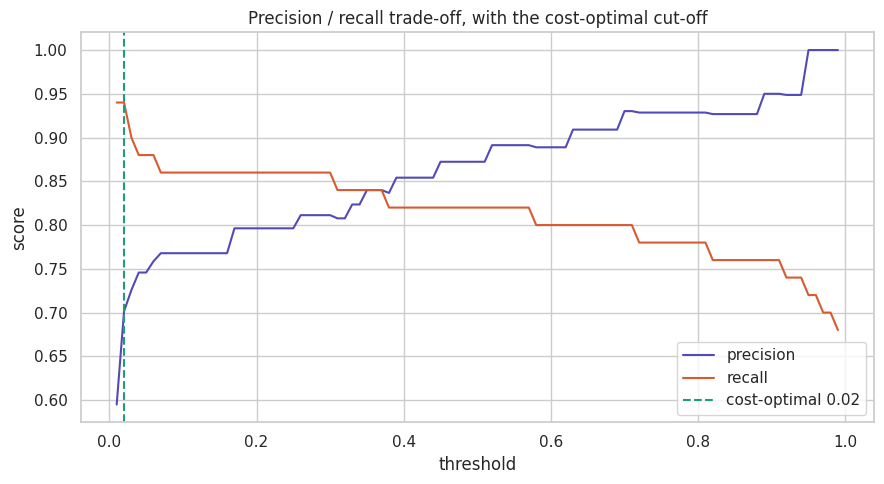

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep['threshold'], sweep['precision'], label='precision', color='#534AB7')
ax.plot(sweep['threshold'], sweep['recall'], label='recall', color='#D85A30')
ax.axvline(best_row['threshold'], color='#1D9E75', ls='--',
           label=f"cost-optimal {best_row['threshold']:.2f}")
ax.set_xlabel('threshold'); ax.set_ylabel('score'); ax.legend()
ax.set_title('Precision / recall trade-off, with the cost-optimal cut-off')
plt.tight_layout(); plt.show()

## Per-10,000-transaction savings & the final recommendation

In [6]:
n_test = len(y)
per_10k = 10_000 / n_test
saving_total = default_row['cost'] - best_row['cost']
saving_10k = saving_total * per_10k

print(f'Test set: {n_test:,} transactions')
print(f'Cost at default 0.50 : {default_row["cost"]:,.0f}')
print(f'Cost at optimal {best_row["threshold"]:.2f} : {best_row["cost"]:,.0f}')
print(f'Saving over the test set: {saving_total:,.0f}')
print(f'Saving per 10,000 transactions: {saving_10k:,.0f}')

Test set: 15,050 transactions
Cost at default 0.50 : 1,830
Cost at optimal 0.02 : 700
Saving over the test set: 1,130
Saving per 10,000 transactions: 751


In [7]:
recommendation = (
    f"Deploy '{best_model}' at a decision threshold of "
    f"{best_row['threshold']:.2f} (not 0.50). At that cut-off it catches "
    f"{best_row['recall']:.0%} of fraud at {best_row['precision']:.0%} "
    f"precision, cutting expected loss by about {saving_10k:,.0f} units "
    f"per 10,000 transactions versus the default threshold."
)
print(recommendation)

Deploy 'xgboost' at a decision threshold of 0.02 (not 0.50). At that cut-off it catches 94% of fraud at 70% precision, cutting expected loss by about 751 units per 10,000 transactions versus the default threshold.


### Takeaways
- A probability is not a decision — the **threshold** is where the model meets the business.
- With asymmetric costs, the optimal threshold is well away from 0.5, and you can compute it exactly.
- The final output is one actionable sentence with a number attached.

---

## What the whole project shows
1. Accuracy is the wrong metric for fraud; AUC-PR is the right one.
2. On static tabular data, gradient boosting is hard to beat; the neural net only matches it with careful regularisation.
3. Under temporal drift, every model degrades — and the neural net degrades hardest, then recovers fastest when retrained.
4. The deployment decision is economic, not statistical: pick the model *and* the threshold *and* the retraining cadence together.